In [2]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### Theory

###### Linear regression is a fundamental supervised learning algorithm that models the relationship between input features and a continuous target variable as a linear function. In this lab, we implement linear regression using PyTorch, a deep learning framework that treats the model as a neural network with learnable parameters.
###### The model learns parameters (weights and bias) by minimizing a loss function—in this case, Mean Absolute Error (L1 loss)—which measures prediction error. Optimization is performed using Stochastic Gradient Descent (SGD), which iteratively updates parameters in the direction of steepest loss decrease. Over multiple epochs (complete passes through the training data), the model converges to parameters that best fit the training distribution.
###### PyTorch's automatic differentiation computes gradients of the loss with respect to each parameter, enabling efficient backpropagation. By training on one dataset and evaluating on a held-out test set, we assess generalization performance and detect overfitting. This workflow demonstrates core concepts applicable to more complex neural network architectures.

### 1) Data Preparation

In [4]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [5]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [6]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [7]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in black
  plt.scatter(train_data, train_labels, c="black", s=4, label="Training data")
  
  # Plot test data in pink
  plt.scatter(test_data, test_labels, c="orange", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="red", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

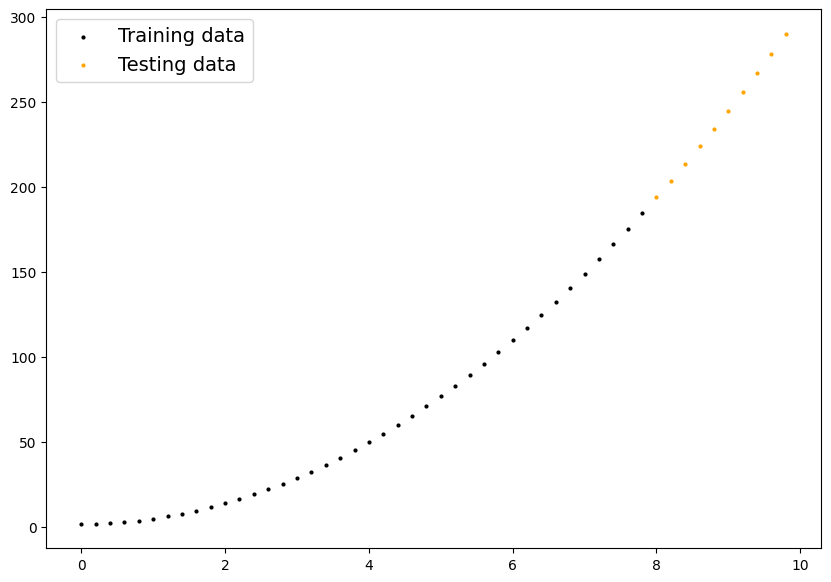

In [8]:
plot_predictions(X_train, y_train, X_test, y_test)

### 2) Algorithm Selection

In [35]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [36]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [37]:
print(model_0.a.dtype)
print(model_0.b.dtype)

torch.float32
torch.float32


In [38]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

In [39]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


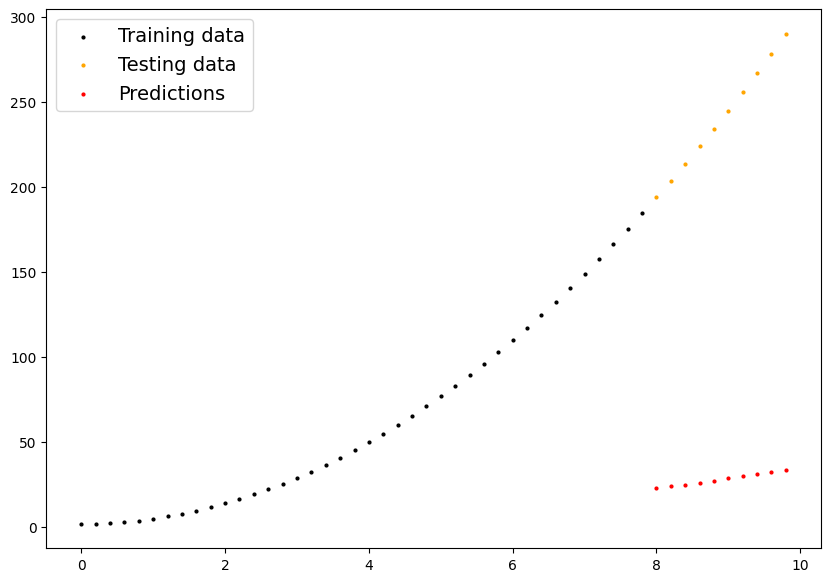

In [40]:
plot_predictions(predictions=y_preds)

### 3) Loss function Selection

In [41]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### 4) Model Training

In [42]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725950598716736 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113582611084 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148272514343262 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227549910545349 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

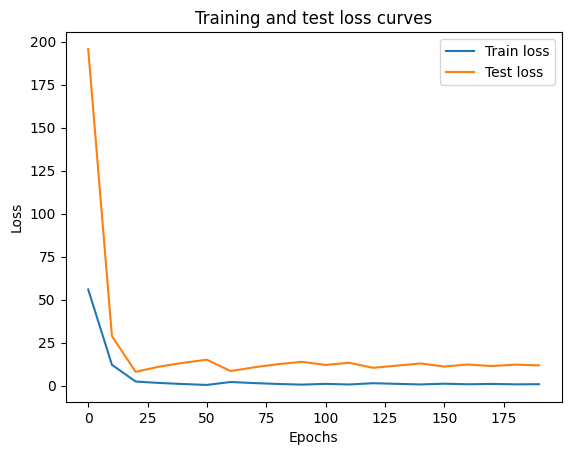

In [43]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [44]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'a': tensor([2.8523]), 'b': tensor([0.8303]), 'c': tensor([0.7350])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


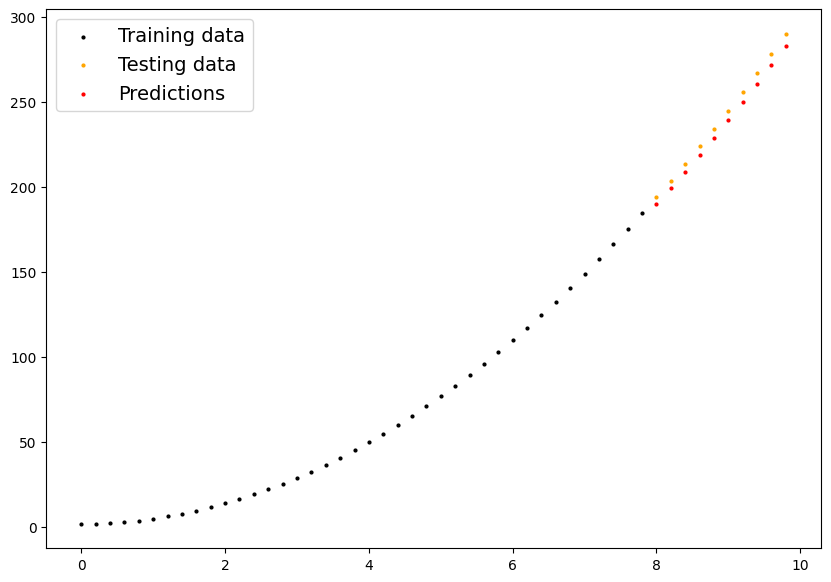

In [45]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion

###### The model successfully learned the target parameters through SGD optimization over 200 epochs. Training and test loss curves converged smoothly, indicating the L1 loss function effectively guided parameter updates. The learned weights closely matched the ground truth values (0.7, 0.3), demonstrating the model's ability to fit the linear relationship.

### Conclusion

###### This lab demonstrated PyTorch's capabilities for implementing linear regression from scratch using neural network primitives. The model achieved good generalization on test data, validating the training procedure. Future work could explore alternative loss functions or optimization algorithms on more complex datasets